# Предсказание уровня удовлетворённости сотрудников и увольнения сотрудника из компании

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён.

**Задача 1:**

Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.

Описание данных:

- `id` — уникальный идентификатор сотрудника;
- `dept` — отдел, в котором работает сотрудник;
- `level` — уровень занимаемой должности;
- `workload` — уровень загруженности сотрудника;
- `employment_years` — длительность работы в компании (в годах);
- `last_year_promo` — показывает, было ли повышение за последний год;
- `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
- `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
- `salary` — ежемесячная зарплата сотрудника;
- `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.

**Задача 2:**

Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

Описание данных:

Данные те же, что и в задаче 1, но добавлен новый целевой признак `quit`.

Импортирование библиотек

In [1]:
!pip install -U scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import make_scorer, roc_auc_score

try:
    import phik
except:
    !pip install phik -q
    import phik
    
import warnings
warnings.filterwarnings('ignore')

     |████████████████████████████████| 13.5 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 68.4 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


## Задача 1

### Загрузка данных

In [2]:
# тренировочная выборка
train_job = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
# входные признаки тестовой выборки
test_job = pd.read_csv('/datasets/test_features.csv')
# целевой признак тестовой выборки
test_target_job = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [3]:
for df in [train_job, test_job, test_target_job]:
    display(df.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Выведем общую информацию о всех таблицах

In [4]:
for df in [train_job, test_job, test_target_job]:
    df.info()
    print('\n/---------------/\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB

/---------------/

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 

Предварительно в данных видны пропуски в столбцах `dept` и `level`

### Предобработка данных

#### Обработка неявных дубликатов и пропусков

In [5]:
for df in [train_job, test_job, test_target_job]:
    for col in df.select_dtypes(exclude='number').columns:
        print(col)
        print(df[col].unique())
        print()

dept
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]

level
['junior' 'middle' 'sinior' nan]

workload
['medium' 'high' 'low']

last_year_promo
['no' 'yes']

last_year_violations
['no' 'yes']

dept
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']

level
['junior' 'middle' 'sinior' nan]

workload
['medium' 'low' 'high' ' ']

last_year_promo
['no' 'yes']

last_year_violations
['no' 'yes']



В таблице `test_X` в столбцах `workload` и `dept` есть неявные пропуски, записаные пробелами, заменим их на nan

In [6]:
test_job.loc[test_job['workload'] == ' ', 'workload'] = np.nan
test_job.loc[test_job['dept'] == ' ', 'dept'] = np.nan

Исправим значение `sinior` в столбце `level` на `senior`

In [7]:
train_job.loc[train_job['level'] == 'sinior', 'level'] = 'senior'
test_job.loc[test_job['level'] == 'sinior', 'level'] = 'senior'

**Вывод:**

Из проблем в данных были выявлены только неявные 

#### Обработка явных дубликатов

In [8]:
for df in [train_job, test_job, test_target_job]:
    print(df.duplicated().sum())

0
0
0


Явных дубликатов нет

### Исследовательский анализ данных

#### Исследование отдельных признаков

In [9]:
# функция вывода характеристик количественного признака
def feature_stat_quant(feature, title, ylabel, bins_count=50):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=bins_count)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)
    
# функция для построения графика категориальных переменных
def feature_stat_categ(feature, title_name, ylim=100):
    plt.figure(figsize=(10,6)) 
    
    percent_list = []
    for j in range(len(sorted(feature.unique()))):
        percent_list.append(((feature == sorted(feature.unique())[j]).sum() / feature.size)*100)
        
    bars = plt.bar(sorted(feature.unique()), percent_list,
              color=['blue','skyblue', 'red', 'lightcoral', 'green', 'lightgreen'], alpha=0.8, width=0.6)
    for i, v in enumerate(percent_list):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.xticks(rotation=45)
    plt.title(title_name)
    plt.ylabel('% от общего числа')
    plt.ylim(0, ylim)
    plt.show()
    
# функция для построения графика дискретных переменных
def feature_stat_discrete(feature, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(feature, color='blue')
    plt.title(title)
    plt.show()
    print(feature.describe().T)

##### Отдел `dept`

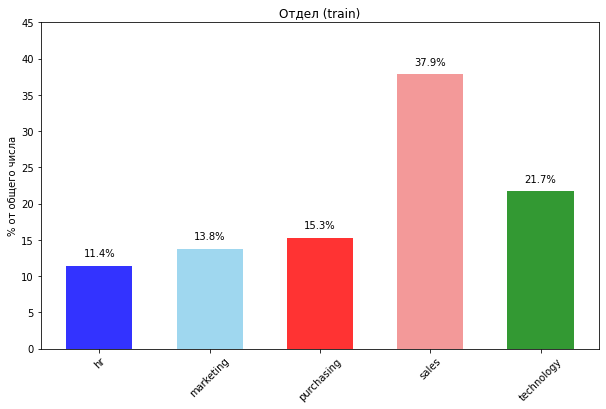

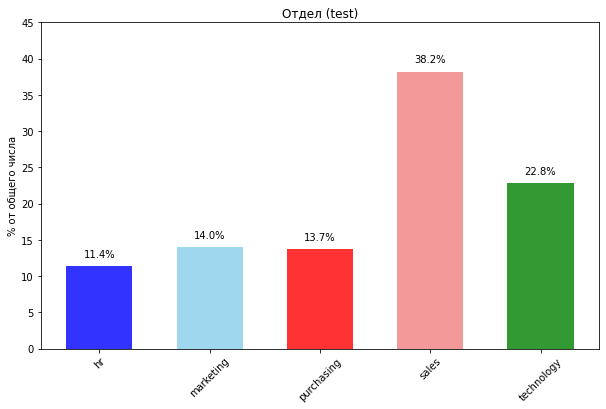

In [10]:
feature_stat_categ(train_job['dept'].dropna(), 'Отдел (train)', ylim=45)
feature_stat_categ(test_job['dept'].dropna(), 'Отдел (test)', ylim=45)

В обоих выборках с отрывом больше сотруднико отдела `sales`. Относительно друг друга значения в выборках распределены одинаково.

##### Уровень должности (`level`)

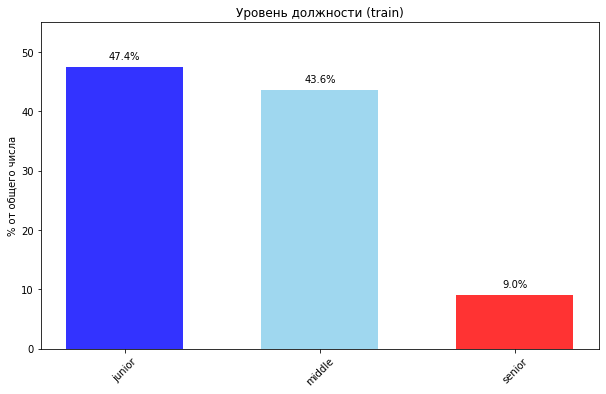

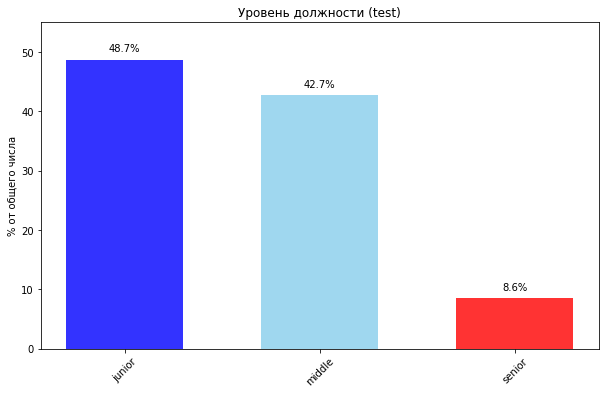

In [11]:
feature_stat_categ(train_job['level'].dropna(), 'Уровень должности (train)', ylim=55)
feature_stat_categ(test_job['level'].dropna(), 'Уровень должности (test)', ylim=55)

Больше всего в обоих выборках сотрудников уровня `junior` и `middle`, меньше всего (около 9%) уровня `senior`

##### Уровень загруженности (`workload`)

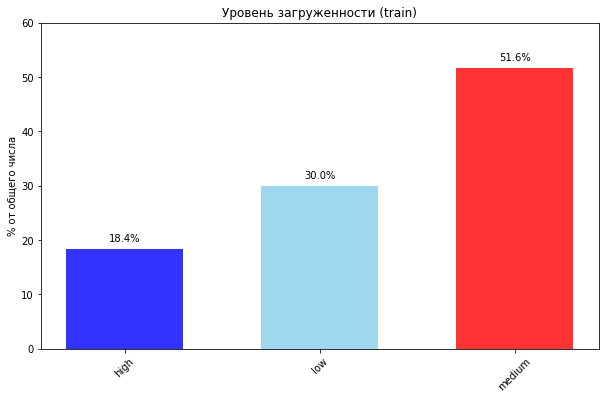

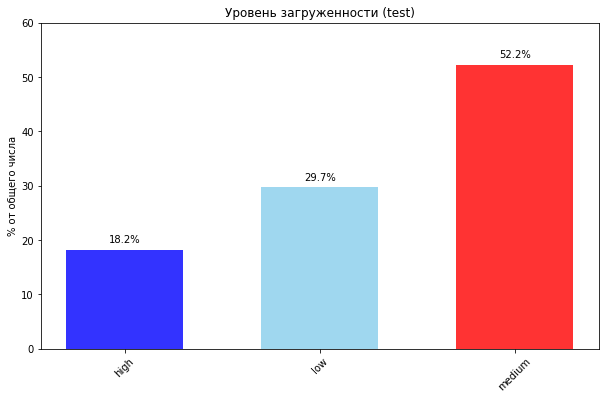

In [12]:
feature_stat_categ(train_job['workload'], 'Уровень загруженности (train)', ylim=60)
feature_stat_categ(test_job['workload'].dropna(), 'Уровень загруженности (test)', ylim=60)

В обоих выборках половина сотрудников имеет загруженность уровня `medium`. `low` и `high` имеют 30% и 18% сотрудников соответственно

##### Длительность работы в компании (`employment_years`)

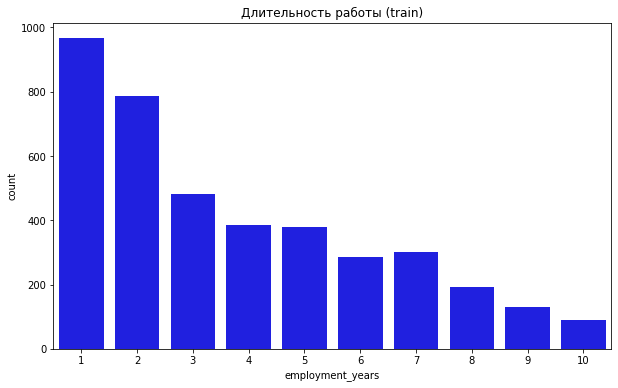

count    4000.000000
mean        3.718500
std         2.542513
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


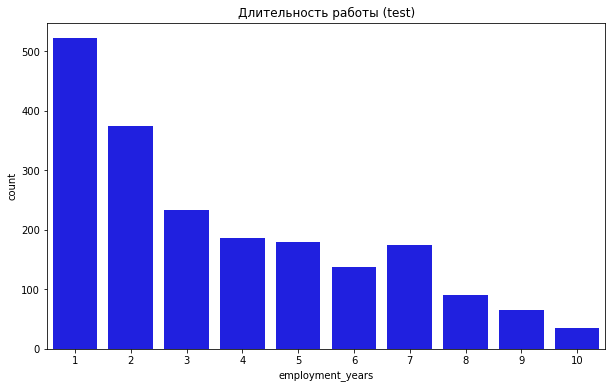

count    2000.000000
mean        3.666500
std         2.537222
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


In [13]:
feature_stat_discrete(train_job['employment_years'], 'Длительность работы (train)')
feature_stat_discrete(test_job['employment_years'], 'Длительность работы (test)')

Распределение данных напоминает Пуассоновское, относительно друг друга выборки распределены одинаково

##### Было ли повышение за последний год (`last_year_promo`)

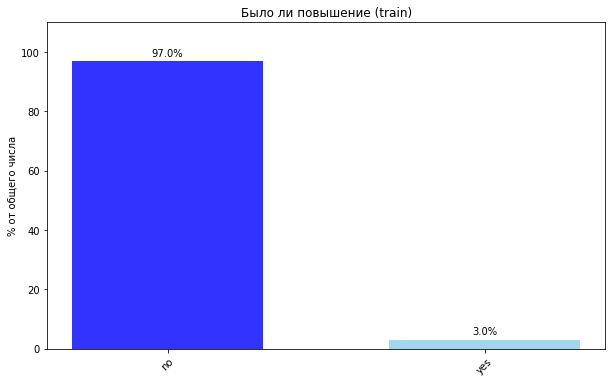

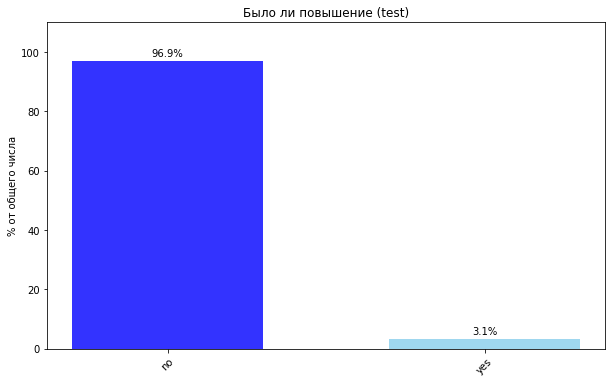

In [14]:
feature_stat_categ(train_job['last_year_promo'], 'Было ли повышение (train)', ylim=110)
feature_stat_categ(test_job['last_year_promo'], 'Было ли повышение (test)', ylim=110)

3% сотрудников было повышено за последний год в обоих выборках

##### Нарушал ли сотрудник трудовой договор за последний год (`last_year_violations`)

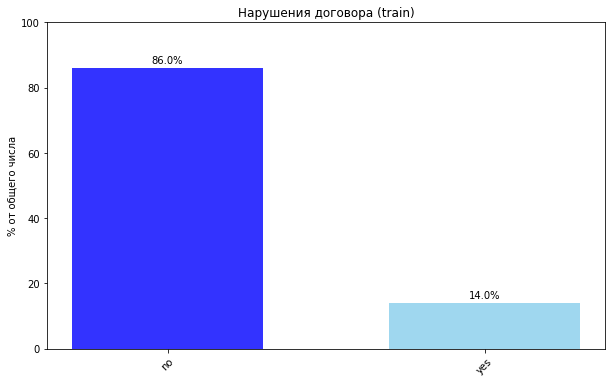

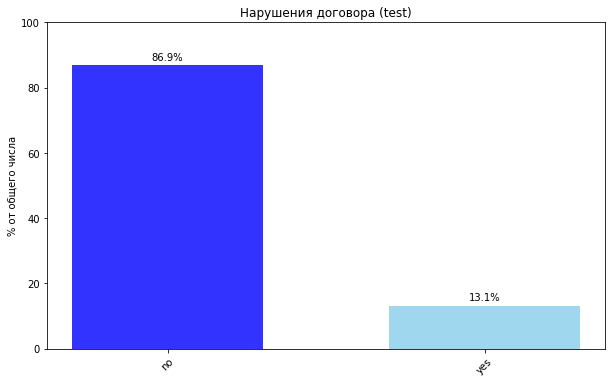

In [15]:
feature_stat_categ(train_job['last_year_violations'], 'Нарушения договора (train)')
feature_stat_categ(test_job['last_year_violations'], 'Нарушения договора (test)')

В обоих выборках 13% сотрудников нарушали договор за последий год

##### Оценка качества работы сотрудника (`supervisor_evaluation`)

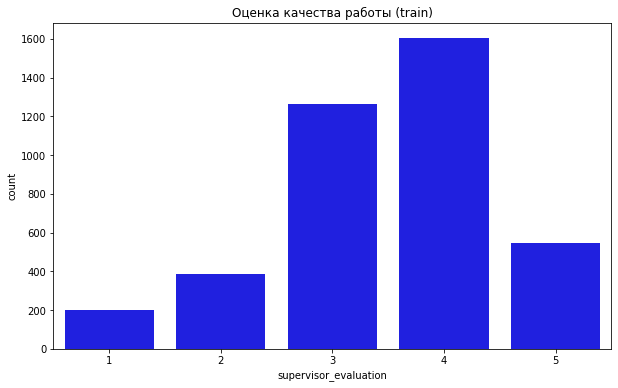

count    4000.000000
mean        3.476500
std         1.008812
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


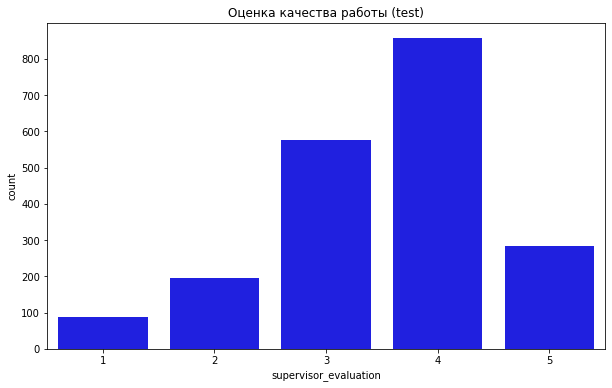

count    2000.000000
mean        3.526500
std         0.996892
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [16]:
feature_stat_discrete(train_job['supervisor_evaluation'], 'Оценка качества работы (train)')
feature_stat_discrete(test_job['supervisor_evaluation'], 'Оценка качества работы (test)')

Выборки распределены одинаково нормально со смещением всправо.

##### Зарплата (`salary`)

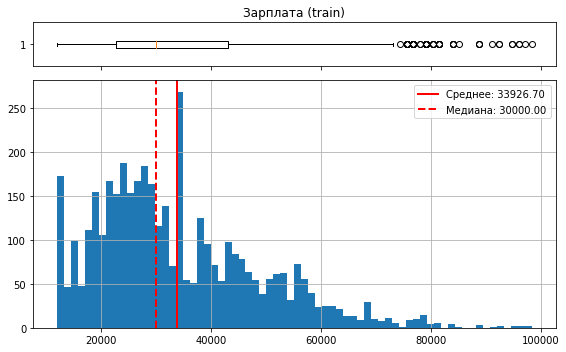

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64


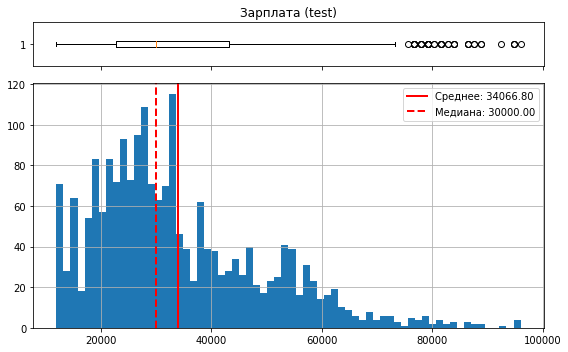

count     2000.000000
mean     34066.800000
std      15398.436729
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64


In [17]:
feature_stat_quant(train_job['salary'], 'Зарплата (train)', '',
                   len(train_job['salary'].unique()))
feature_stat_quant(test_job['salary'], 'Зарплата (test)', '',
                   len(test_job['salary'].unique()))

Распределение зарплат похоже на нормальное с выбросами справа, удалим значения превышающие 70000 из тренировочной выборки

In [18]:
train_job = train_job.loc[train_job['salary'] <= 70000]

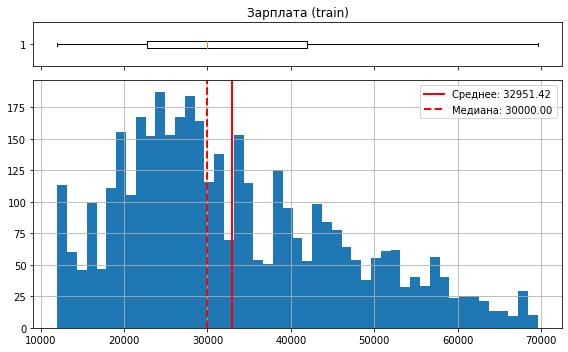

count     3915.000000
mean     32951.417625
std      13453.846612
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      42000.000000
max      69600.000000
Name: salary, dtype: float64


In [19]:
feature_stat_quant(train_job['salary'], 'Зарплата (train)', '',
                   len(train_job['salary'].unique()))

Распределение стало более нормальным

##### Уровень удовлетворённости сотрудника (`job_satisfaction_rate`)

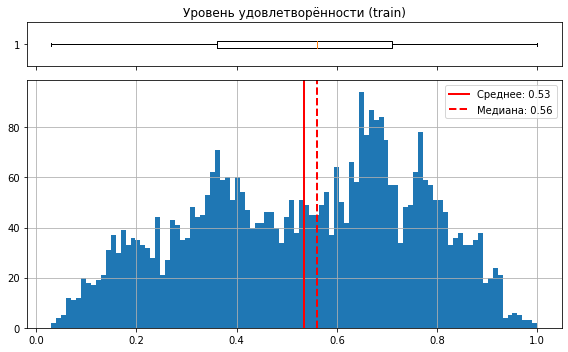

count    3915.000000
mean        0.533556
std         0.224961
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64


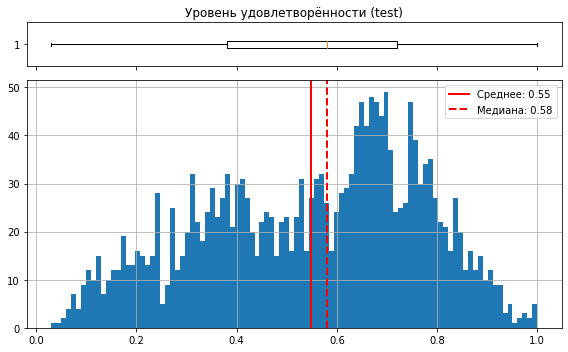

count    2000.00000
mean        0.54878
std         0.22011
min         0.03000
25%         0.38000
50%         0.58000
75%         0.72000
max         1.00000
Name: job_satisfaction_rate, dtype: float64


In [20]:
feature_stat_quant(train_job['job_satisfaction_rate'], 'Уровень удовлетворённости (train)', '',
                   len(train_job['job_satisfaction_rate'].unique()))
feature_stat_quant(test_target_job['job_satisfaction_rate'], 'Уровень удовлетворённости (test)', '',
                   len(test_target_job['job_satisfaction_rate'].unique()))

Выборки распределены одинаково нормально с небольшим смещением вправо

### Корреляционный анализ

Рассчитаем коэффициенты корреляции

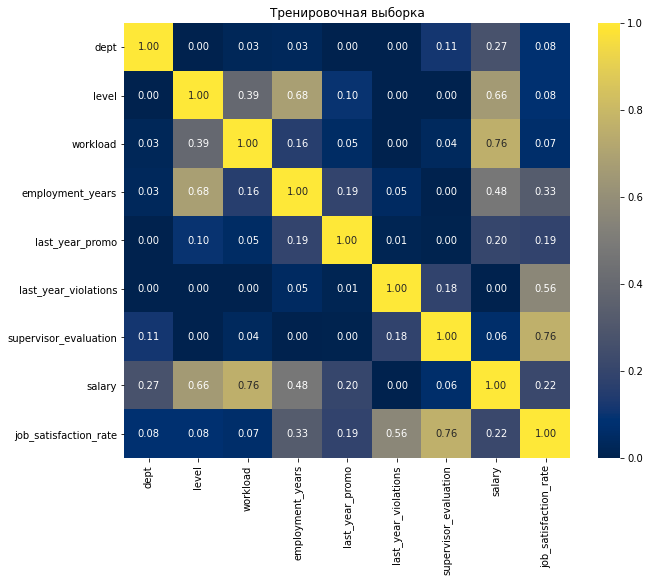

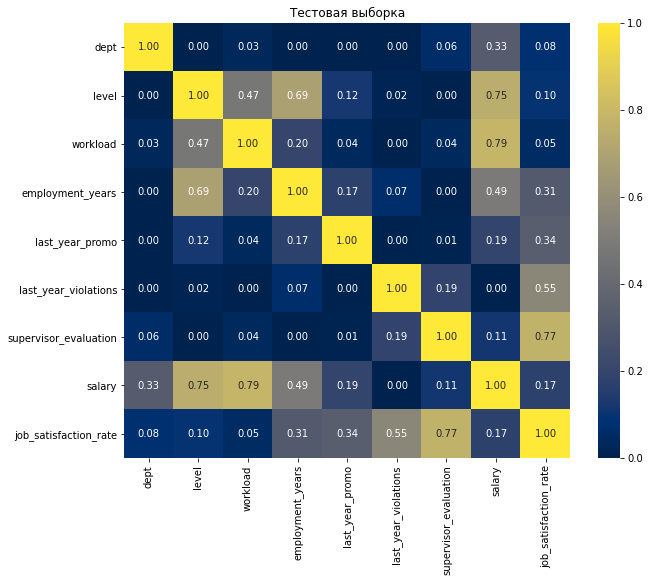

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_job.drop('id', axis=1).phik_matrix(interval_cols=
            train_job.drop(['id', 'employment_years', 'supervisor_evaluation'], axis=1).select_dtypes(include='number').columns
                                    ), annot=True, fmt='.2f', cmap='cividis')
plt.title('Тренировочная выборка')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(test_job.merge(test_target_job, on='id').drop('id', axis=1).phik_matrix(interval_cols=
    test_job.merge(test_target_job, on='id').drop(['id', 'employment_years', 'supervisor_evaluation'], axis=1).select_dtypes(include='number').columns
                                    ), annot=True, fmt='.2f', cmap='cividis')
plt.title('Тестовая выборка')
plt.show()

У целевого признака `job_satisfaction_rate` самый большой коэффициент корреляции с `supervisor_evaluation`. Мультиколлинеарности не наблюдается. Корреляции признаков на тренировочной и тестовой выборках совпадают.

Построим диагрыммы рассеяния для тренировочной выборки

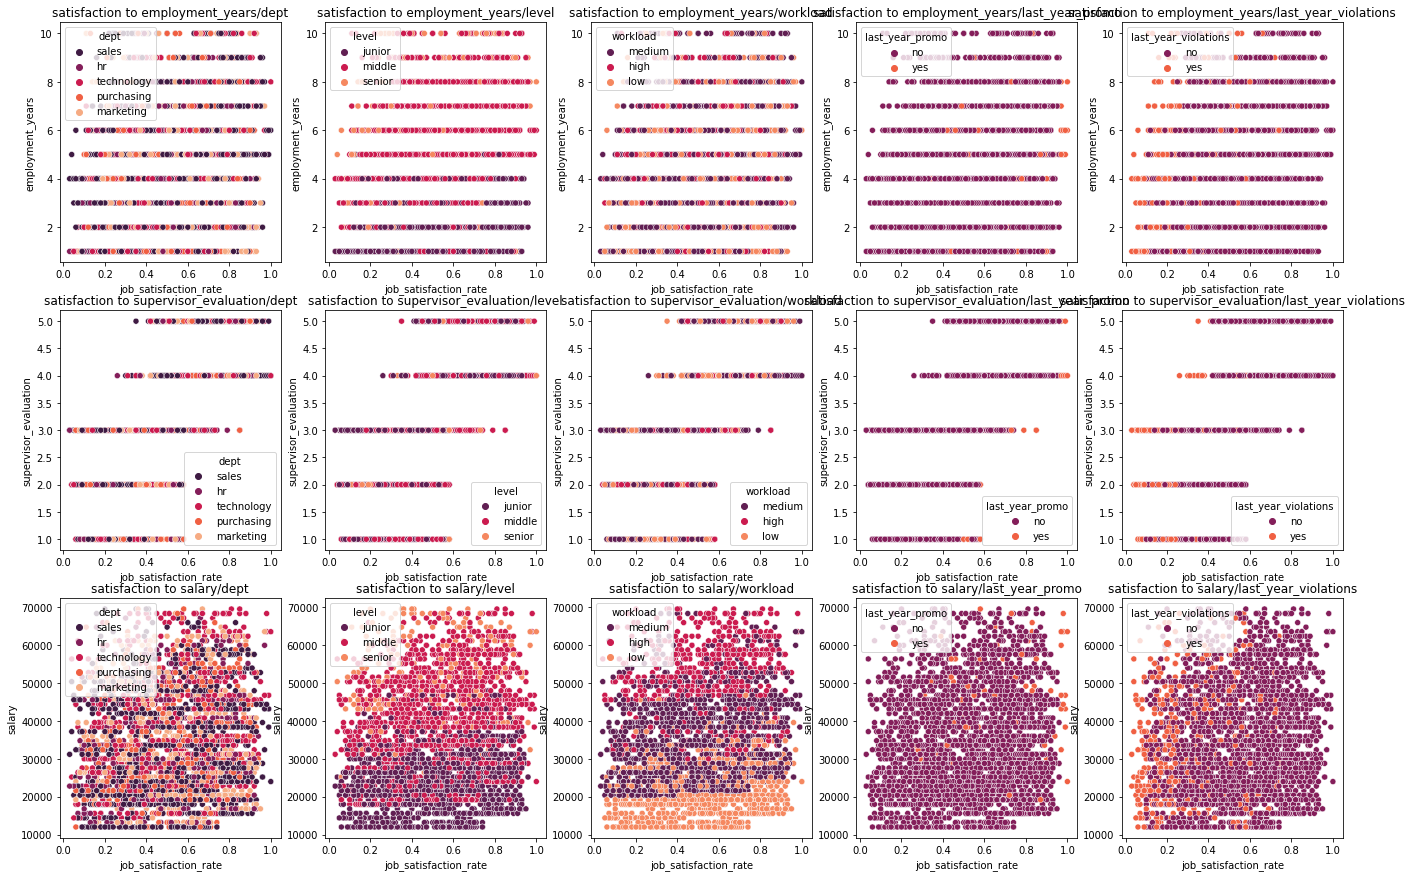

In [22]:
fig, axes = plt.subplots(3, 5, figsize=(23, 15))
axes = axes.flatten()

index = 0
for quant in train_job.drop(['id', 'job_satisfaction_rate'], axis=1).select_dtypes(include='number').columns:
    for categ in train_job.drop('id', axis=1).select_dtypes(exclude='number').columns:
        sns.scatterplot(data=train_job.drop('id', axis=1), x='job_satisfaction_rate', y=quant,
                    hue=categ, ax=axes[index], palette='rocket')
        axes[index].set_title(f'satisfaction to {quant}/{categ}')
        index += 1
plt.show()

Нелинейных зависимостей не наблюдается, из закономерностей можно увидеть, что чем больше загруженность, тем больше зарплата, а уровень удовлетворённости ниже у тех, кто нарушал трудовой договор

Построим диаграммы рассеяния для тестовой выборки

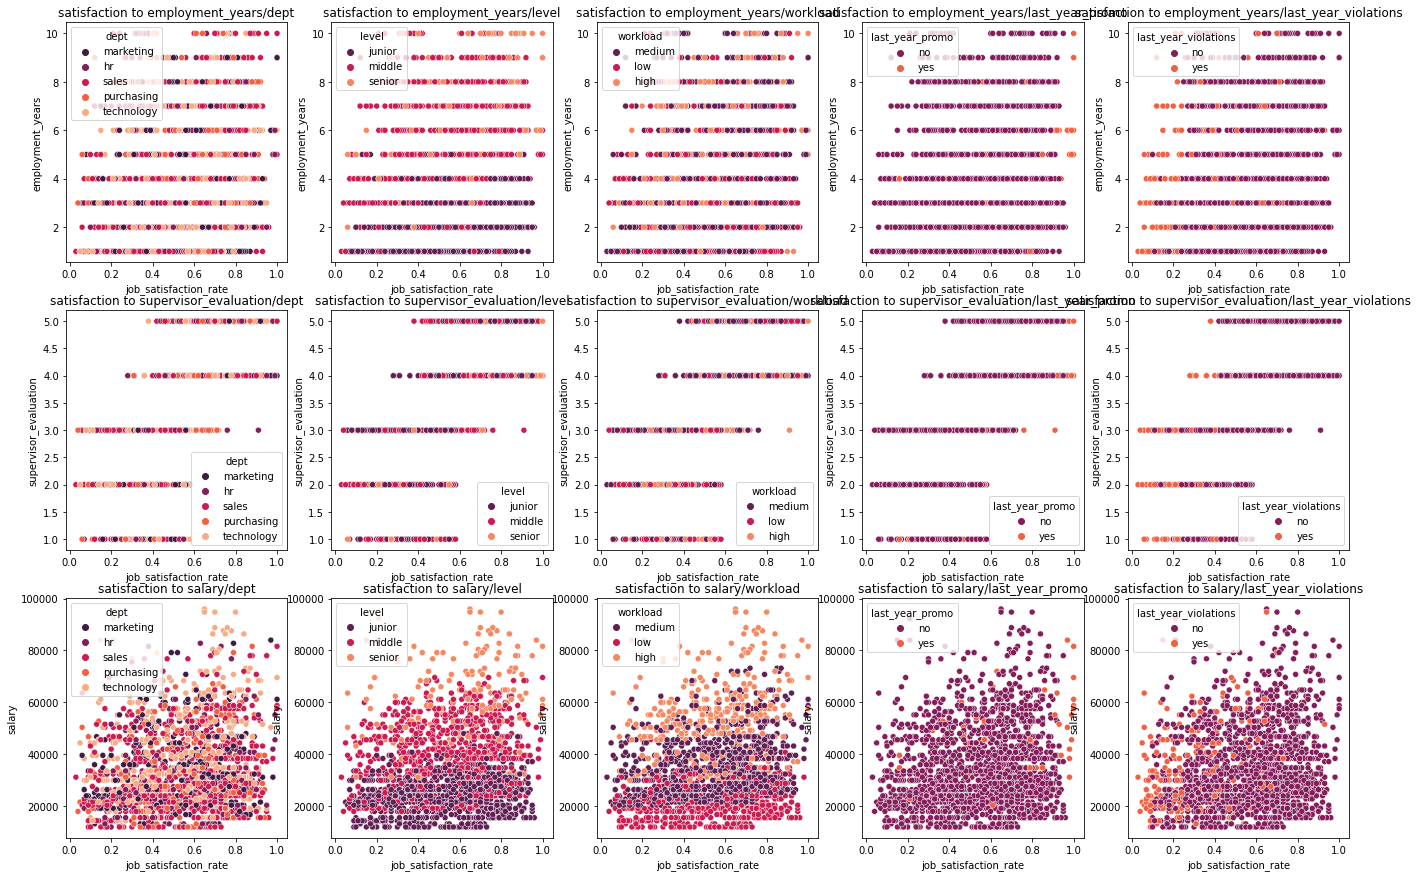

In [23]:
fig, axes = plt.subplots(3, 5, figsize=(23, 15))
axes = axes.flatten()

index = 0
for quant in test_job.merge(test_target_job, on='id').drop(['id', 'job_satisfaction_rate'], axis=1).select_dtypes(include='number').columns:
    for categ in test_job.merge(test_target_job, on='id').drop('id', axis=1).select_dtypes(exclude='number').columns:
        sns.scatterplot(data=test_job.merge(test_target_job, on='id').drop('id', axis=1), x='job_satisfaction_rate', y=quant,
                    hue=categ, ax=axes[index], palette='rocket')
        axes[index].set_title(f'satisfaction to {quant}/{categ}')
        index += 1
plt.show()

Графики тестовой выборки не отличаются от графиков тренировочной

### Обучение модели

#### Создание пайплайнов

In [24]:
RANDOM_STATE = 42

Разделим признаки на типы

In [25]:
ohe_cols = ['dept', 'last_year_promo', 'last_year_violations']
ord_cols = ['level', 'workload']
num_cols = train_job.drop(['id', 'job_satisfaction_rate'], axis=1).select_dtypes(include='number').columns.tolist()

Создадим пайплайны

In [26]:
ohe_pipe = Pipeline([
    ('imputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe_step', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [27]:
ord_pipe = Pipeline([
    ('imputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord_step', OrdinalEncoder(
        categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
        handle_unknown='use_encoded_value', unknown_value=np.nan
        )),
    ('imputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

In [28]:
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_cols),
    ('ord', ord_pipe, ord_cols),
    ('num', StandardScaler(), num_cols)
])

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

#### Создание метрики SMAPE

In [29]:
# функция метрики SMAPE
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    summ = 0
    for i in range(y_true.size):
        summ += abs(y_true[i] - y_pred[i]) / ((abs(y_true[i]) + abs(y_pred[i])) / 2)
    return (100 / y_true.size) * summ

smape_scorer = make_scorer(
    smape,
    greater_is_better=False
)

#### Обучение модели с подбором гиперпараметров с помощью `RandomizedSearchCV`

In [30]:
param_grid=[
    # словарь LinearRegression()
    {
        'models' : [LinearRegression()],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()]
    },

    # словарь DecisionTreeRegressor()
    {
        'models' : [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth' : range(2,20),
        'models__min_samples_leaf' : range(1, 10),
        'models__min_samples_split' : range(2, 10),
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()],
    }

]

Создадим объект кросс-валидационного поиска, обучим его, выведем лучшую модель и лучшую метрику.

In [31]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(train_job.drop(['id', 'job_satisfaction_rate'], axis=1), train_job['job_satisfaction_rate'])

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на кросс-валидационной выборке:', -randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('imputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe_step',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer_before_ord',


Проверим лучшую модель на тестовой выборке

In [32]:
test_job = test_job.sort_values(by='id')
test_target_job = test_target_job.sort_values(by='id')
test_job['job_satisfaction_rate'] = randomized_search.best_estimator_.predict(test_job.drop('id', axis=1))
smape(test_target_job['job_satisfaction_rate'], test_job['job_satisfaction_rate'])

13.91497349009483

Проверим модель на адекватность, сравнив её предсказания с качеством модели, предсказывающей константу

In [33]:
dummy_reg = DummyRegressor()
dummy_reg.fit(train_job.drop(['id', 'job_satisfaction_rate'], axis=1), train_job['job_satisfaction_rate'])
dummy_smape = smape(test_target_job["job_satisfaction_rate"], dummy_reg.predict(test_job.drop("id", axis=1)))
print(f'Метрика SMAPE dummy-модели: {dummy_smape}')
if dummy_smape <= 15:
    print('Тест на адекватность не пройден')
else:
    print('Тест на адекватность пройден')

Метрика SMAPE dummy-модели: 38.23248228397687
Тест на адекватность пройден


#### Вывод

Лучшее результаты показали следующие настройки:
- Использование StandardScaler на количественных признаках
- DecisionTreeRegressor со следующими гиперпараметрами: 
    - max_depth = 12
    - min_samples_split = 6
    - min_samples_leaf = 3
- Метрика SMAPE лучшей модели на кросс-валидации: 14.56
- Метрика SMAPE лучшей модели на тестовой выборке: 13.91

Модель прошла тест на адекватность

## Задача 2

### Загрузка и предобработка данных данных

In [34]:
# тренировочная выборка
train_quit = pd.read_csv('/datasets/train_quit.csv')
# входные признаки тестовой выборки (совпадают с предыдущей задачей)
test_quit = test_job
# целевой признак тестовой выборки
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')

In [35]:
for df in [train_quit, test_quit, test_target_quit]:
    display(df.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1172,100298,hr,junior,low,2,no,no,4,19200,0.837586
852,100480,marketing,junior,low,4,no,no,4,16800,0.852000
848,100503,purchasing,middle,high,5,no,no,4,55200,0.784200
524,100610,sales,middle,medium,5,no,no,4,43200,0.815667
476,100692,sales,middle,high,6,no,no,4,48000,0.685200


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Выведем общую информацию о всех таблицах

In [36]:
for df in [train_quit, test_quit, test_target_quit]:
    df.info()
    print('\n/---------------/\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB

/---------------/

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 1172 to 1844
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  ---

Предварительно в данных видны пропуски в столбцах `dept` и `level`

In [37]:
for df in [train_quit, test_quit, test_target_quit]:
    for col in df.select_dtypes(exclude='number').columns:
        print(col)
        print(df[col].unique())
        print()

dept
['sales' 'purchasing' 'marketing' 'technology' 'hr']

level
['middle' 'junior' 'sinior']

workload
['high' 'medium' 'low']

last_year_promo
['no' 'yes']

last_year_violations
['no' 'yes']

quit
['no' 'yes']

dept
['hr' 'marketing' 'purchasing' 'sales' 'technology' nan]

level
['junior' 'middle' 'senior' nan]

workload
['low' 'high' 'medium' nan]

last_year_promo
['no' 'yes']

last_year_violations
['no' 'yes']

quit
['yes' 'no']



Исправим грамматическую ошибку в признаке `level` в таблице `train_quit`, заменив `sinior` на `senior`

In [38]:
train_quit.loc[train_quit['level'] == 'sinior', 'level'] = 'senior'

Построим графики распределения зарплаты (`salary`) в тренировочной выборке

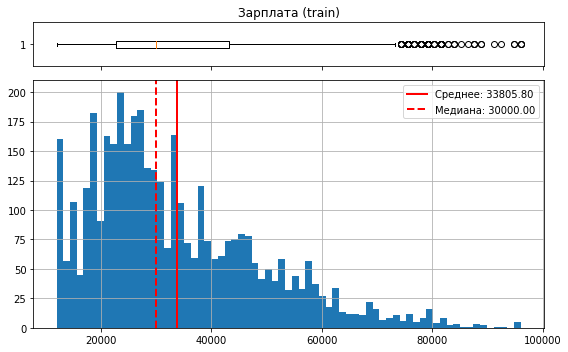

count     4000.000000
mean     33805.800000
std      15152.415163
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64


In [39]:
feature_stat_quant(train_quit['salary'], 'Зарплата (train)', '',
                   len(train_quit['salary'].unique()))

Распределение зарплат похоже на нормальное с выбросами справа, удалим значения превышающие 70000 из тренировочной выборки

In [40]:
train_quit = train_quit.loc[train_quit['salary'] <= 70000]

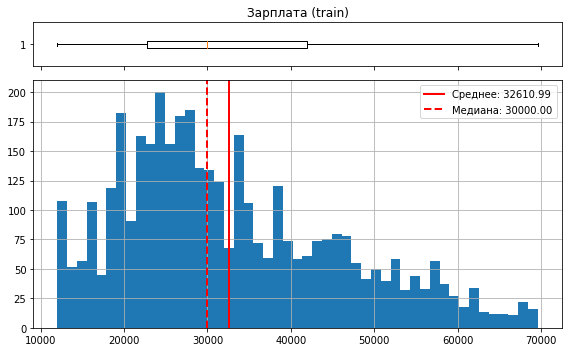

count     3896.000000
mean     32610.985626
std      13409.290457
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      42000.000000
max      69600.000000
Name: salary, dtype: float64


In [41]:
feature_stat_quant(train_quit['salary'], 'Зарплата (train)', '',
                   len(train_quit['salary'].unique()))

Распределение стало более нормальным

### Исследовательский анализ данных

#### Исследование отдельных признаков

##### Отдел `dept`

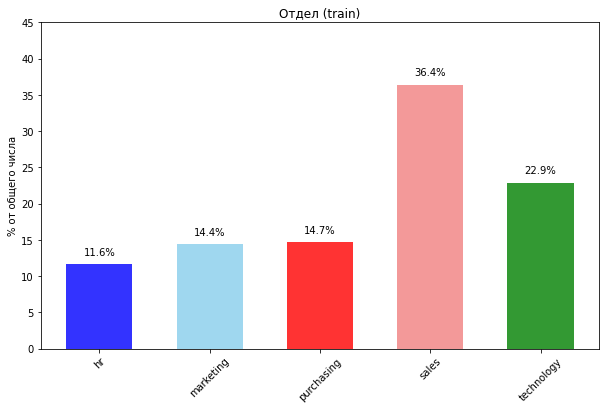

In [42]:
feature_stat_categ(train_quit['dept'].dropna(), 'Отдел (train)', ylim=45)

С отрывом больше сотруднико отдела `sales`

##### Уровень должности (`level`)

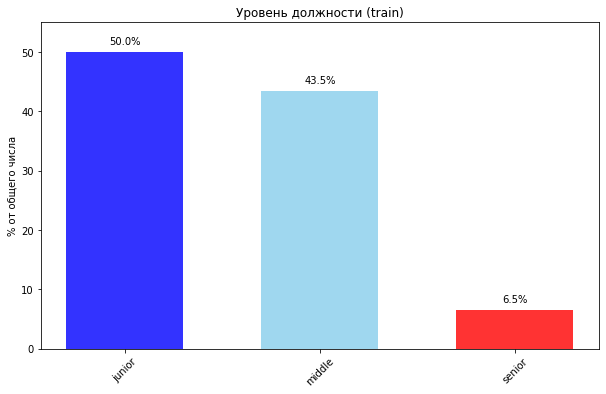

In [43]:
feature_stat_categ(train_quit['level'].dropna(), 'Уровень должности (train)', ylim=55)

Больше всего сотрудников уровня `junior` и `middle`, меньше всего уровня `senior`

##### Уровень загруженности (`workload`)

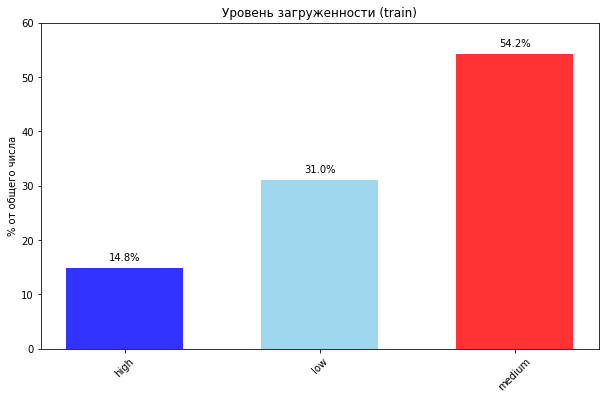

In [44]:
feature_stat_categ(train_quit['workload'], 'Уровень загруженности (train)', ylim=60)

Половина сотрудников имеет загруженность уровня `medium`. `low` и `high` значительно меньше.

##### Длительность работы в компании (`employment_years`)

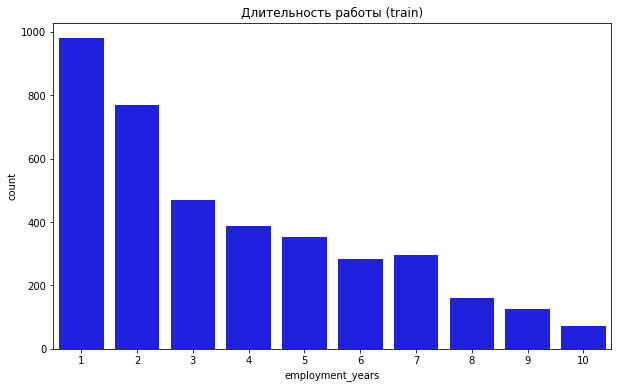

count    3896.000000
mean        3.632957
std         2.498222
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        10.000000
Name: employment_years, dtype: float64


In [45]:
feature_stat_discrete(train_quit['employment_years'], 'Длительность работы (train)')

Распределение данных напоминает Пуассоновское

##### Было ли повышение за последний год (`last_year_promo`)

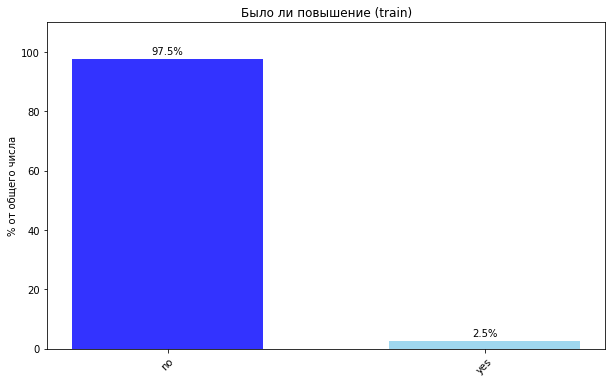

In [46]:
feature_stat_categ(train_quit['last_year_promo'], 'Было ли повышение (train)', ylim=110)

2.5% сотрудников было повышено за последний год в обоих выборках

##### Нарушал ли сотрудник трудовой договор за последний год (`last_year_violations`)

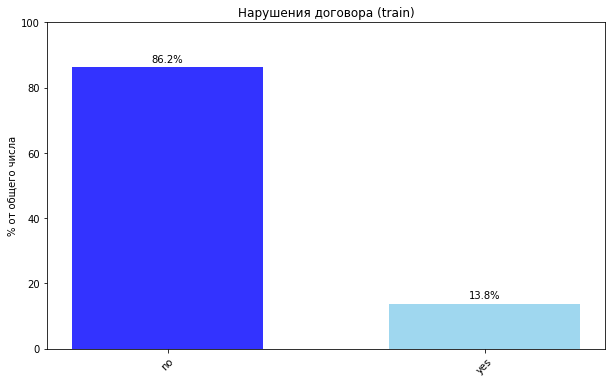

In [47]:
feature_stat_categ(train_quit['last_year_violations'], 'Нарушения договора (train)')

13.8% сотрудников нарушали договор за последий год

##### Оценка качества работы сотрудника (`supervisor_evaluation`)

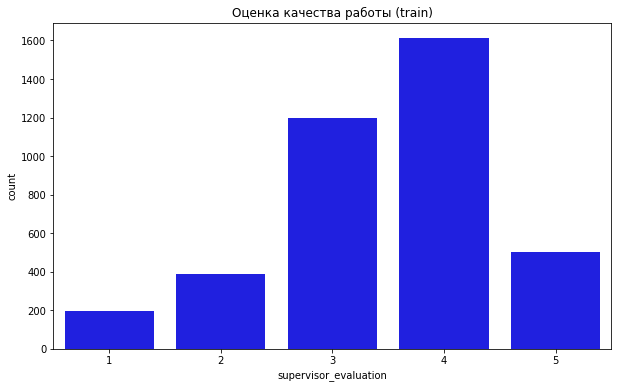

count    3896.000000
mean        3.470483
std         1.005071
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [48]:
feature_stat_discrete(train_quit['supervisor_evaluation'], 'Оценка качества работы (train)')

Данные распределены нормально со смещением всправо.

#### Выявление портрета уволившегося сотрудника

In [49]:
# функция построения графика сравнения распределений количественной переменной у уволившихся сотрудников и нет
def quant_quit_compare_plot(feature):
    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
    axes[0].hist(train_quit.loc[train_quit['quit'] == 'no', feature],
             bins=len(train_quit.loc[train_quit['quit'] == 'no', feature].unique()))
    axes[0].set_title(feature + ' (не уволившиеся, train)')
    axes[0].axvline(train_quit.loc[train_quit["quit"] == "no", feature].mean(), color='red', linestyle='-', linewidth=2,
                    label=f'Среднее: {train_quit.loc[train_quit["quit"] == "no", feature].mean():.2f}')
    axes[0].legend()
    
    axes[1].hist(train_quit.loc[train_quit['quit'] == 'yes', feature],
             bins=len(train_quit.loc[train_quit['quit'] == 'yes', feature].unique()))
    axes[1].set_title(feature + ' (уволившиеся, train)')
    axes[1].axvline(train_quit.loc[train_quit["quit"] == "yes", feature].mean(), color='red', linestyle='-', linewidth=2,
                    label=f'Среднее: {train_quit.loc[train_quit["quit"] == "yes", feature].mean():.2f}')
    axes[1].legend()
    
    plt.show()
    print(f'Среднее значение {feature} среди не уволившихся: {round(train_quit.loc[train_quit["quit"] == "no", feature].mean(), 2)}')
    print(f'Среднее значение {feature} среди    уволившихся: {round(train_quit.loc[train_quit["quit"] == "yes", feature].mean(), 2)}')

##### Отдел (`dept`)

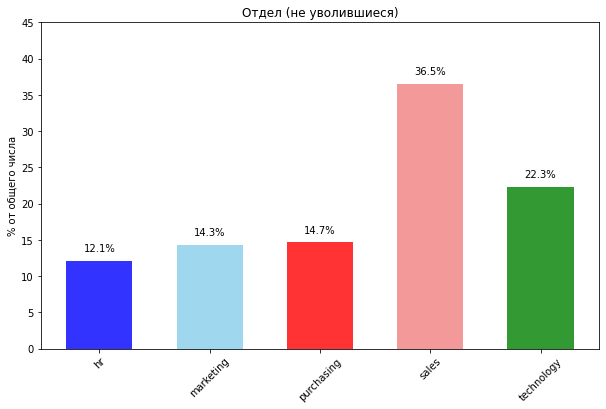

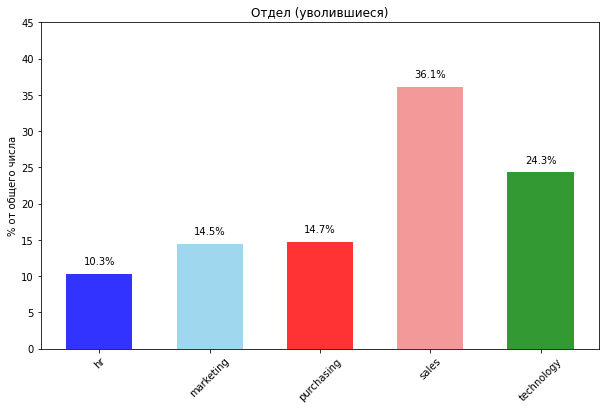

In [50]:
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'no', 'dept'].dropna(), 'Отдел (не уволившиеся)', ylim=45)
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'yes', 'dept'].dropna(), 'Отдел (уволившиеся)', ylim=45)

Разницы между уволившимися и не уволившимися нет

##### Уровень должности (`level`)

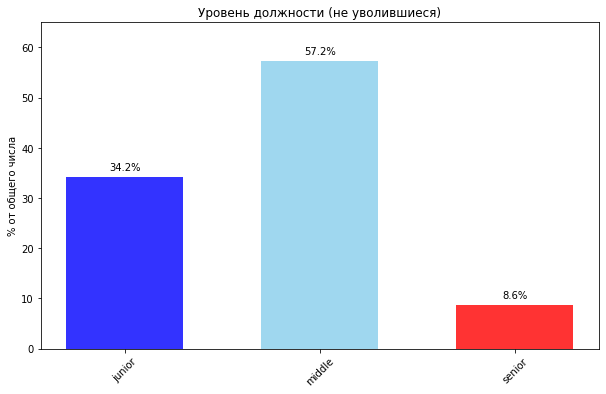

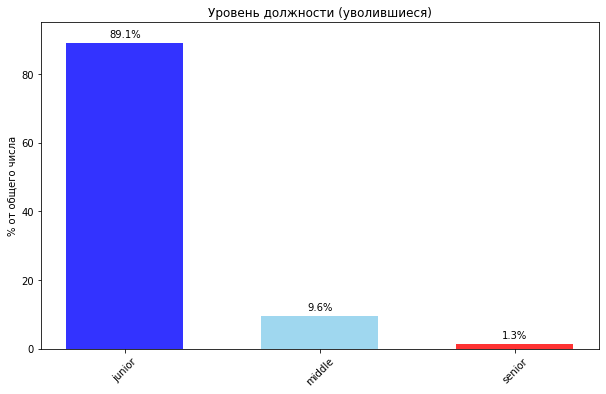

In [51]:
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'no', 'level'].dropna(), 'Уровень должности (не уволившиеся)', ylim=65)
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'yes', 'level'].dropna(), 'Уровень должности (уволившиеся)', ylim=95)

Увольняются в основном сотрудники, занимающие должность `junior`

##### Уровень загруженности (`workload`)

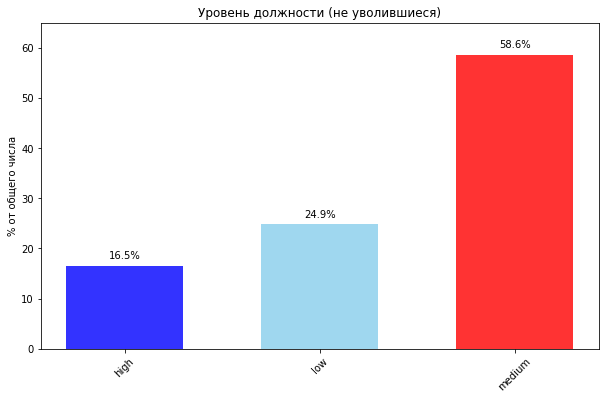

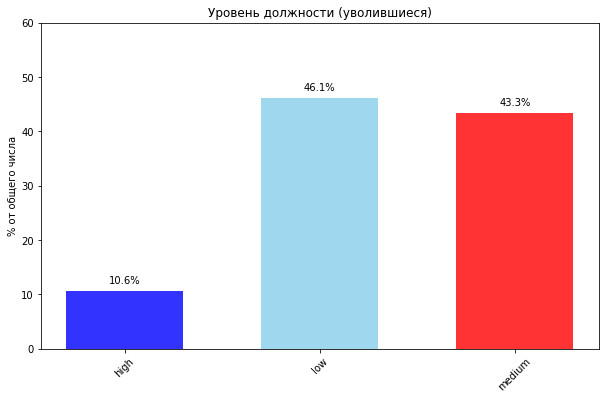

In [52]:
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'no', 'workload'].dropna(), 'Уровень должности (не уволившиеся)', ylim=65)
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'yes', 'workload'].dropna(), 'Уровень должности (уволившиеся)', ylim=60)

Больше всего уволившихся с низкой или средней нагруженностью.

##### Длительность работы в компании (`employment_years`)

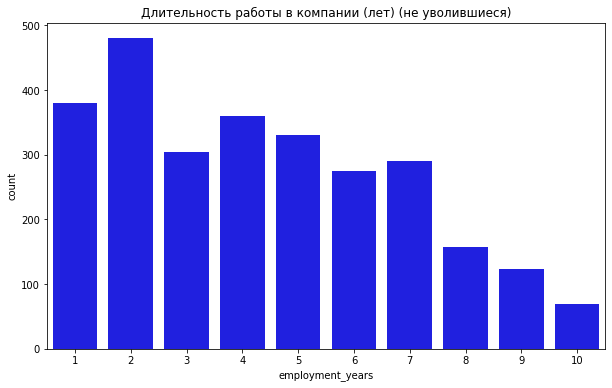

count    2770.000000
mean        4.363899
std         2.508576
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


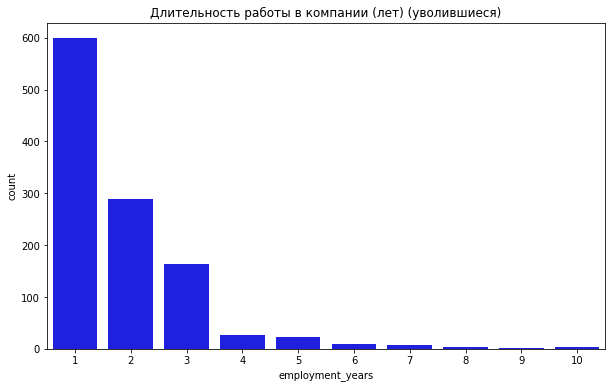

count    1126.000000
mean        1.834813
std         1.251941
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: employment_years, dtype: float64


In [53]:
feature_stat_discrete(train_quit.loc[train_quit['quit'] == 'no', 'employment_years'],
                      'Длительность работы в компании (лет) (не уволившиеся)')
feature_stat_discrete(train_quit.loc[train_quit['quit'] == 'yes', 'employment_years'],
                      'Длительность работы в компании (лет) (уволившиеся)')

Распределение длительности работы уволившихся сотрудников сильно смещено влево, следовательно увольняются сотрудники, мало проработавшие в компании.

##### Было ли повышение за последний год (`last_year_promo`)

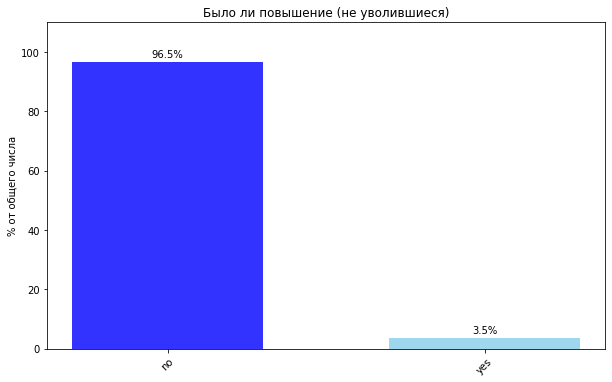

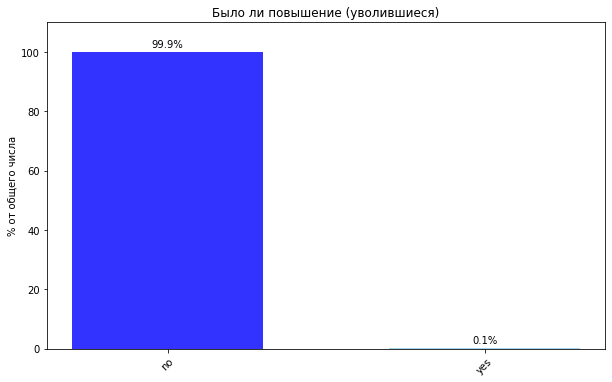

In [54]:
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'no', 'last_year_promo'].dropna(), 'Было ли повышение (не уволившиеся)', ylim=110)
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'yes', 'last_year_promo'].dropna(), 'Было ли повышение (уволившиеся)', ylim=110)

Сотрудников, которые били повышены, в целом меньше 5%, но среди уволившихся их практически нет.

##### Нарушал ли сотрудник трудовой договор за последний год (`last_year_violations`)

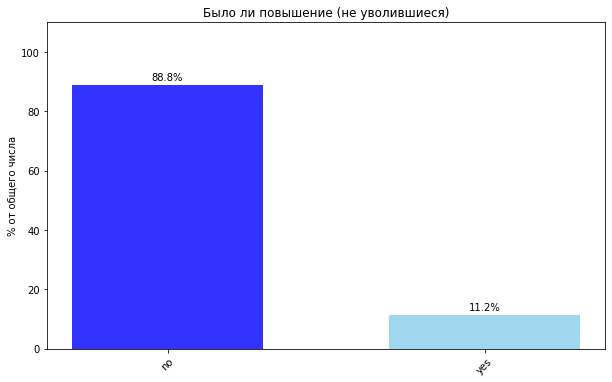

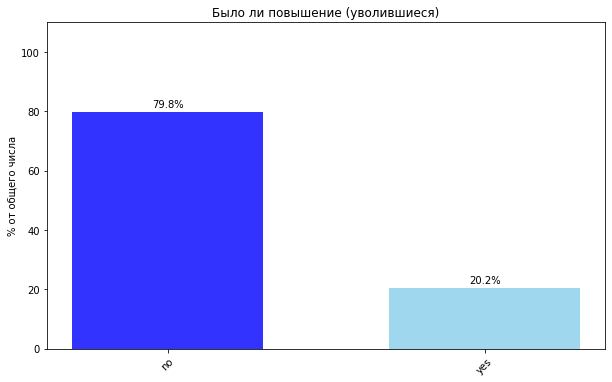

In [55]:
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'no', 'last_year_violations'].dropna(), 'Было ли повышение (не уволившиеся)', ylim=110)
feature_stat_categ(train_quit.loc[train_quit['quit'] == 'yes', 'last_year_violations'].dropna(), 'Было ли повышение (уволившиеся)', ylim=110)

Среди уволившихся сотрудников на 10% больше нарушавших договор

##### Оценка качества работы сотрудника (`supervisor_evaluation`)

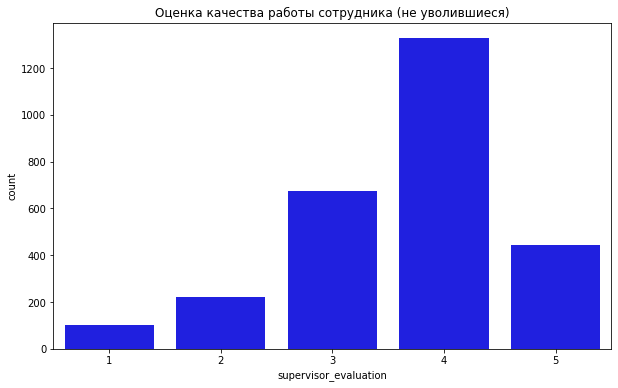

count    2770.000000
mean        3.643682
std         0.965515
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


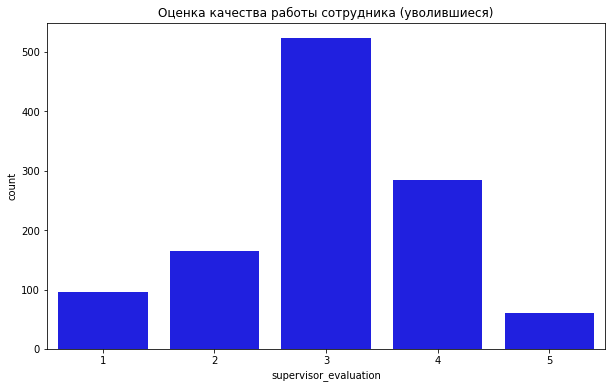

count    1126.000000
mean        3.044405
std         0.973324
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [56]:
feature_stat_discrete(train_quit.loc[train_quit['quit'] == 'no', 'supervisor_evaluation'],
                      'Оценка качества работы сотрудника (не уволившиеся)')
feature_stat_discrete(train_quit.loc[train_quit['quit'] == 'yes', 'supervisor_evaluation'],
                      'Оценка качества работы сотрудника (уволившиеся)')

Оценка качества работы уволившихся сотрудников немного меньше

##### Зарплата (`salary`)

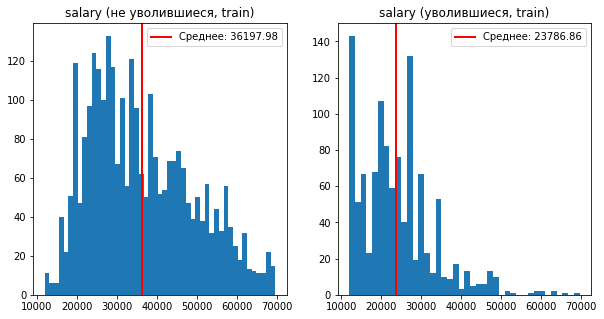

Среднее значение salary среди не уволившихся: 36197.98
Среднее значение salary среди    уволившихся: 23786.86


In [57]:
quant_quit_compare_plot('salary')

Распределение зарплат уволившихся сотрудников смещено влево, в среднем уволившийся сотрудник зарабатывал на 12000 меньше, чем тот, кто не уволился

##### Уровень удовлетворённости сотрудника (`job_satisfaction_rate`)

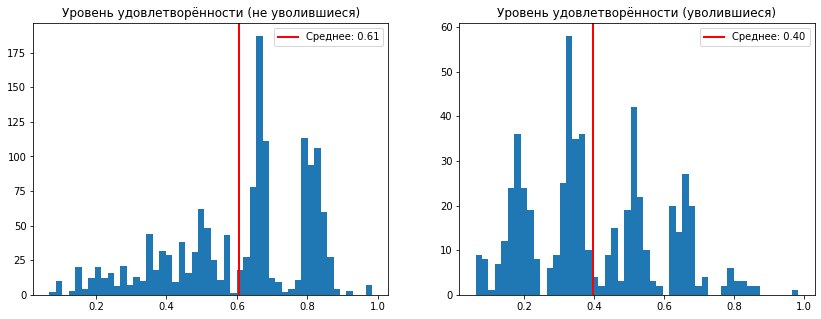

Среднее значение уровня удовлетворённости среди не уволившихся: 0.61
Среднее значение уровня удовлетворённости среди уволившихся: 0.4


In [58]:
test_quit_full = test_quit.merge(test_target_quit, on='id')

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 5))
axes[0].hist(test_quit_full.loc[test_quit_full['quit'] == 'no', 'job_satisfaction_rate'], bins=50)
axes[0].set_title('Уровень удовлетворённости (не уволившиеся)')
axes[0].axvline(test_quit_full.loc[test_quit_full['quit'] == 'no', 'job_satisfaction_rate'].mean(),
                color='red', linestyle='-', linewidth=2,
                label=f'Среднее: {test_quit_full.loc[test_quit_full["quit"] == "no", "job_satisfaction_rate"].mean():.2f}')
axes[0].legend()

axes[1].hist(test_quit_full.loc[test_quit_full['quit'] == 'yes', 'job_satisfaction_rate'], bins=50)
axes[1].set_title('Уровень удовлетворённости (уволившиеся)')
axes[1].axvline(test_quit_full.loc[test_quit_full['quit'] == 'yes', 'job_satisfaction_rate'].mean(),
                color='red', linestyle='-', linewidth=2,
                label=f'Среднее: {test_quit_full.loc[test_quit_full["quit"] == "yes", "job_satisfaction_rate"].mean():.2f}')
axes[1].legend()

plt.show()
print(f'Среднее значение уровня удовлетворённости среди не уволившихся: {round(test_quit_full.loc[test_quit_full["quit"] == "no", "job_satisfaction_rate"].mean(), 2)}')
print(f'Среднее значение уровня удовлетворённости среди уволившихся: {round(test_quit_full.loc[test_quit_full["quit"] == "yes", "job_satisfaction_rate"].mean(), 2)}')

Уровень удовлетворённости уволившихся сотрудников в среднем меньше на 0.21 единицы

#### Добавление признака `job_satisfaction_rate`

Уровент удовлетворённости действительно влияет на то уволится сотрудник или нет

Добавим признак `job_satisfaction_rate` в `train_quit` и `test_quit`

In [60]:
train_quit['job_satisfaction_rate'] = randomized_search.best_estimator_.predict(train_quit.drop(['id', 'quit'], axis=1))
test_quit['job_satisfaction_rate'] = randomized_search.best_estimator_.predict(test_quit.drop('id', axis=1))

#### Вывод

Портрет "уволившегося сотрудника":

- Занимает должность `junior`
- Имеет низкую или среднюю загруженность
- Проработал около 2 лет
- Не был повышен за последний год
- Имеет оценку качества работы `3`
- Зарплата около 23700 рублей
- Уровень удовлетворённости около `0.4`

### Корреляционный анализ

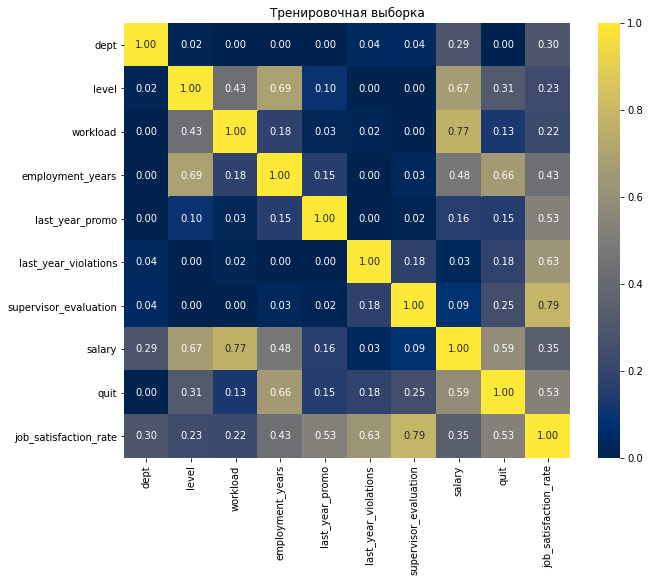

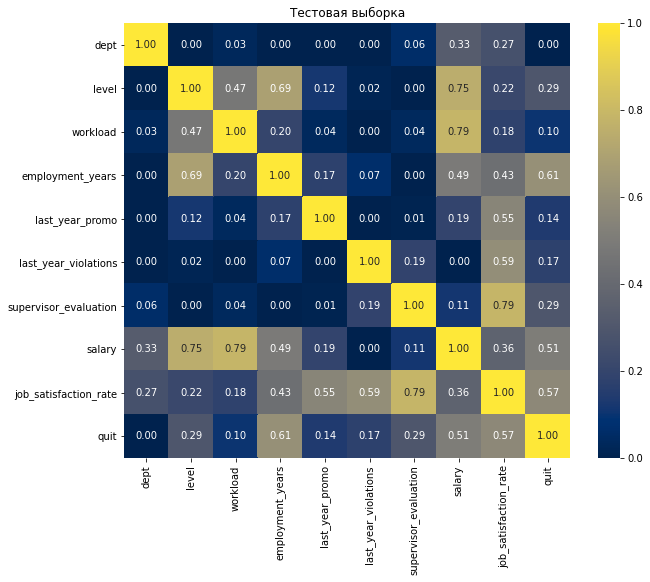

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_quit.drop('id', axis=1).phik_matrix(interval_cols=
        train_job.drop(['id', 'employment_years', 'supervisor_evaluation'], axis=1).select_dtypes(include='number').columns
        ), annot=True, fmt='.2f', cmap='cividis')
plt.title('Тренировочная выборка')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(test_quit.merge(test_target_quit, on='id').drop('id', axis=1).phik_matrix(interval_cols=
           test_quit.merge(test_target_quit, on='id').drop(['id', 'employment_years', 'supervisor_evaluation'], axis=1).select_dtypes(include='number').columns
           ), annot=True, fmt='.2f', cmap='cividis')
plt.title('Тестовая выборка')
plt.show()

У целевого признака `quit` наблюдается заметная корреляция с признаками `employment_years`, `salary` и `job_satisfaction_rate`

Мультиколлинеарности не наблюдается

Корреляции признаков на тренировочной и тестовой выборках совпадают

### Обучение модели

In [206]:
# кодирование целевого признака
le = LabelEncoder()
train_quit['quit'] = le.fit_transform(train_quit['quit'])
test_target_quit['quit'] = le.transform(test_target_quit['quit'])
le.classes_

array(['no', 'yes'], dtype=object)

In [207]:
num_cols.append('job_satisfaction_rate')

In [208]:
param_grid = [
    # словарь LogisticRegression()
    {
        'models' : [LogisticRegression(random_state=RANDOM_STATE)],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()]
    },
    
    # словарь KNeighborsClassifier()
    {
        'models' : [KNeighborsClassifier()],
        'models__n_neighbors' : range(1, 20),
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()]
    },
    
    # словарь DecisionTreeClassifier
    {
        'models' : [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth' : range(2, 20),
        'models__min_samples_leaf' : range(1, 10),
        'models__min_samples_split' : range(2, 10),
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()]
    }
]

In [209]:
randomized_search_quit = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search_quit.fit(train_quit.drop(['id', 'quit'], axis=1), train_quit['quit'])

print('Лучшая модель и её параметры:\n\n', randomized_search_quit.best_estimator_)
print ('Метрика лучшей модели на кросс-валидации:', randomized_search_quit.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('imputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe_step',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer_before_ord',


Проверим лучшую модель на тестовой выборке

In [ ]:
test_quit = test_quit.sort_values(by='id')
test_target_quit = test_target_quit.sort_values(by='id')
test_quit['quit'] = randomized_search_quit.best_estimator_.predict(test_quit.drop('id', axis=1))
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(test_target_quit["quit"], randomized_search_quit.best_estimator_.predict_proba(test_quit.drop(["id", "quit"], axis=1))[:, 1])}')

Проверим модель на адекватность, сравнив её предсказания с качеством модели, предсказывающей константу

In [ ]:
dummy_class = DummyClassifier(random_state=RANDOM_STATE)
dummy_class.fit(train_quit.drop(['id', 'quit'], axis=1), train_quit['quit'])
dummy_roc_auc = roc_auc_score(test_target_quit["quit"], dummy_class.predict_proba(test_job.drop('id', axis=1))[:,1])
print(f'Метрика ROC-AUC dummy-модели: {dummy_roc_auc}')
if dummy_roc_auc >= 0.91:
    print('Тест на адекватность не пройден')
else:
    print('Тест на адекватность пройден')

Лучшее результаты показали следующие настройки:
- Использование StandardScaler на количественных признаках
- DecisionTreeClassifier со следующими гиперпараметрами: 
    - max_depth = 7
    - min_samples_split = 4
    - min_samples_leaf = 7
- Метрика ROC-AUC лучшей модели на кросс-валидации: 0.928
- Метрика ROC-AUC лучшей модели на тестовой выборке: 0.926

Модель прошла тест на адекватность

### Выводы

По полученным данным была проведена следующая работа

**Задача 1**

**Предобработка данных**:

- Неявные пропуски, записанные пробелами заменены на `np.nan`
- Исправлена грамматическая ошибка в столбце `level`

**Исследовательский аналих данных**:

- Были построены графики распределения признаков
- Из данных о зарплате удалены выбросы

**Корреляционный анализ**:

У целевого признака `job_satisfaction_rate` самый большой коэффициент корреляции с `supervisor_evaluation`. Мультиколлинеарности не наблюдается.

Нелинейных зависимостей не наблюдается, из закономерностей можно увидеть, что чем больше загруженность, тем больше зарплата, а уровень удовлетворённости ниже у тех, кто нарушал трудовой договор

**Обучение модели**:

Был создан пайплайн для подготовки данных с различными скейлерами и кодировщиками и обучения 2 модели. С помощью кросс-валидационного поиска были выявлены лучшие настройки:

Лучшее результаты показали следующие настройки:
- Использование StandardScaler на количественных признаках
- DecisionTreeRegressor со следующими гиперпараметрами: 
    - max_depth = 12
    - min_samples_split = 6
    - min_samples_leaf = 3
- Метрика SMAPE лучшей модели на тренировочной выборке: 14.56
- Метрика SMAPE лучшей модели на тестовой выборке: 13.91

- Модель прошла тест на адекватность

**Задача 2**

**Загрузка и предобработка данных**:

- Были загружены новые тренировочные данные
- Из данных о зарплатах удалены выбросы

**Исследовательский анализ данных**:

- Уровень удовлетворённости действительно влияет на уход их компании

Был составлен портрет "уволившегося сотрудника":

- Занимает должность `junior`
- Имеет низкую или среднюю загруженность
- Проработал около 2 лет
- Не был повышен за последний год
- Имеет оценку качества работы `3`
- Зарплата около 23700 рублей
- Уровень удовлетворённости около `0.4`

**Корреляционный анализ**

У целевого признака `quit` наблюдается заметная корреляция с признаками `employment_years`, `salary` и `job_satisfaction_rate`

Мультиколлинеарности не наблюдается

**Обучение модели**

Был создан пайплайн для подготовки данных с различными скейлерами и кодировщиками и обучения 3 модели. С помощью кросс-валидационного поиска были выявлены лучшие настройки:

Лучшее результаты показали следующие настройки:
- Использование StandardScaler на количественных признаках
- DecisionTreeClassifier со следующими гиперпараметрами: 
    - max_depth = 7
    - min_samples_split = 4
    - min_samples_leaf = 7
- Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.928
- Метрика ROC-AUC лучшей модели на тестовой выборке: 0.926

- Модель прошла тест на адекватность

**Рекомендации заказчику**

С увольнением сотрудников коррелируют 2 признака, на которые можно повлиять: зарплата, уровень удовлетворённости. С уровнем удовлетворённости в свою очередь, из признаков на которые можно повлиять, коррелирует наличие повышения за последний год.

Итого, для снижения уровня увольнений можно повышать сотрудников и увеличивать им зарплату, особенно если их стаж работы - 2 года, так как на этот период приходится больше всего увольнений.